
GRIDWORLD ENVIRONMENT
  S   |  1   |  2   |  3   
  4   |  5   |  6   |  7   
  8   |  9   |  10  |  11  
  12  |  13  |  14  |  G   

S = Start State
G = Terminal Goal State

RUNNING MONTE CARLO PREDICTION

Monte Carlo Prediction completed for 5000 episodes.

LEARNED STATE-VALUE FUNCTION
[[-6.143 -5.039 -4.112 -3.909]
 [-5.071 -3.403 -1.65  -0.667]
 [-4.161 -1.706  1.303  3.964]
 [-3.926 -0.726  4.033  0.   ]]

STATE-VALUE SUMMARY TABLE
 State  Row  Column State Type  Estimated Value  Number of Returns
     0    0       0      Start          -6.1430               5000
     1    0       1     Normal          -5.0385               4352
     2    0       2     Normal          -4.1118               3697
     3    0       3     Normal          -3.9089               2843
     4    1       0     Normal          -5.0714               4344
     5    1       1     Normal          -3.4030               4378
     6    1       2     Normal          -1.6501               4088
     7    1       3  

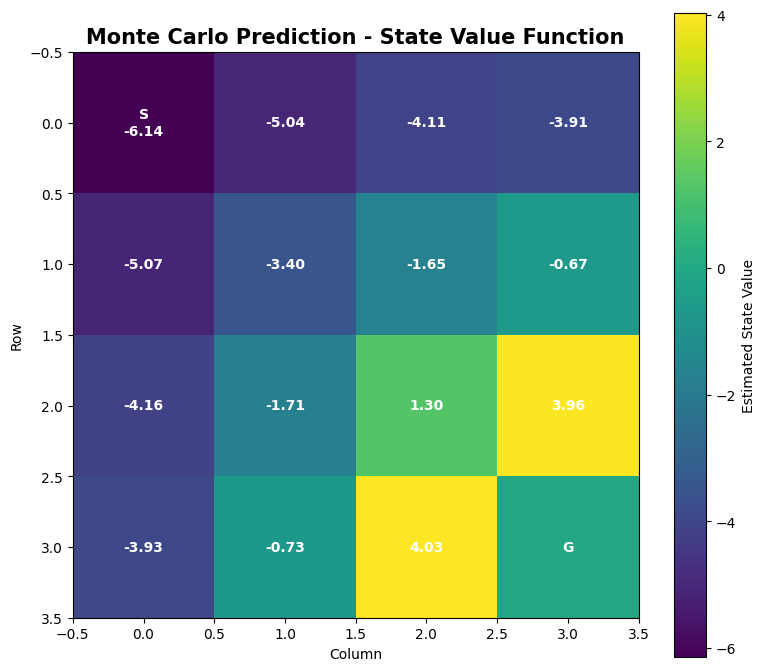

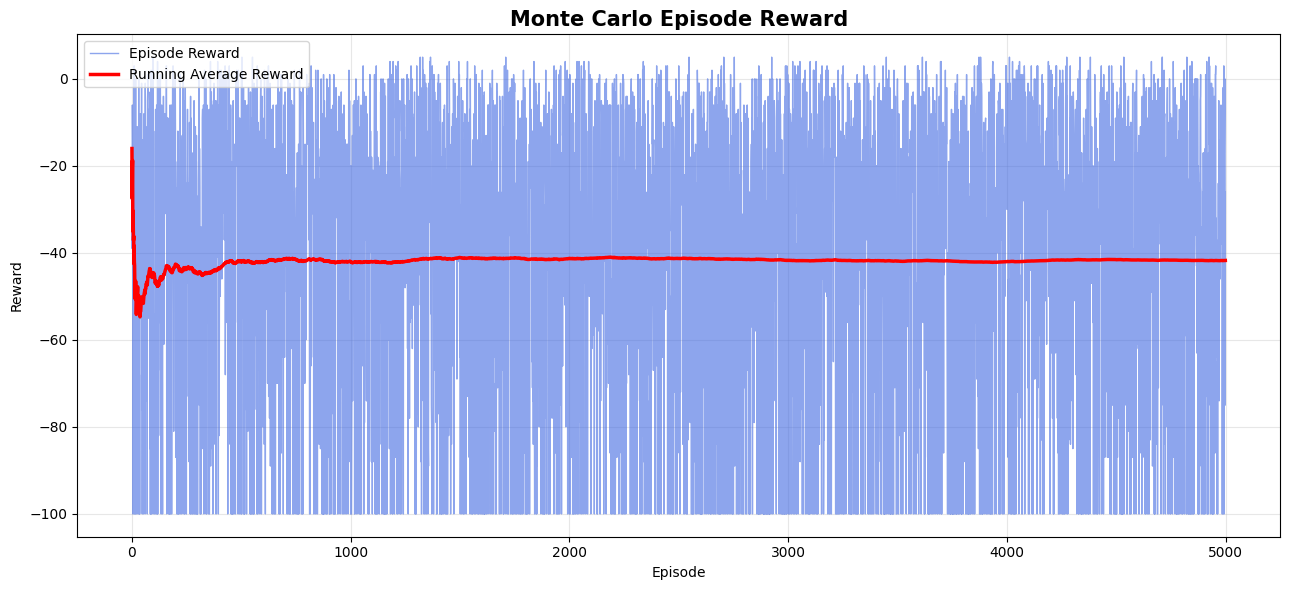

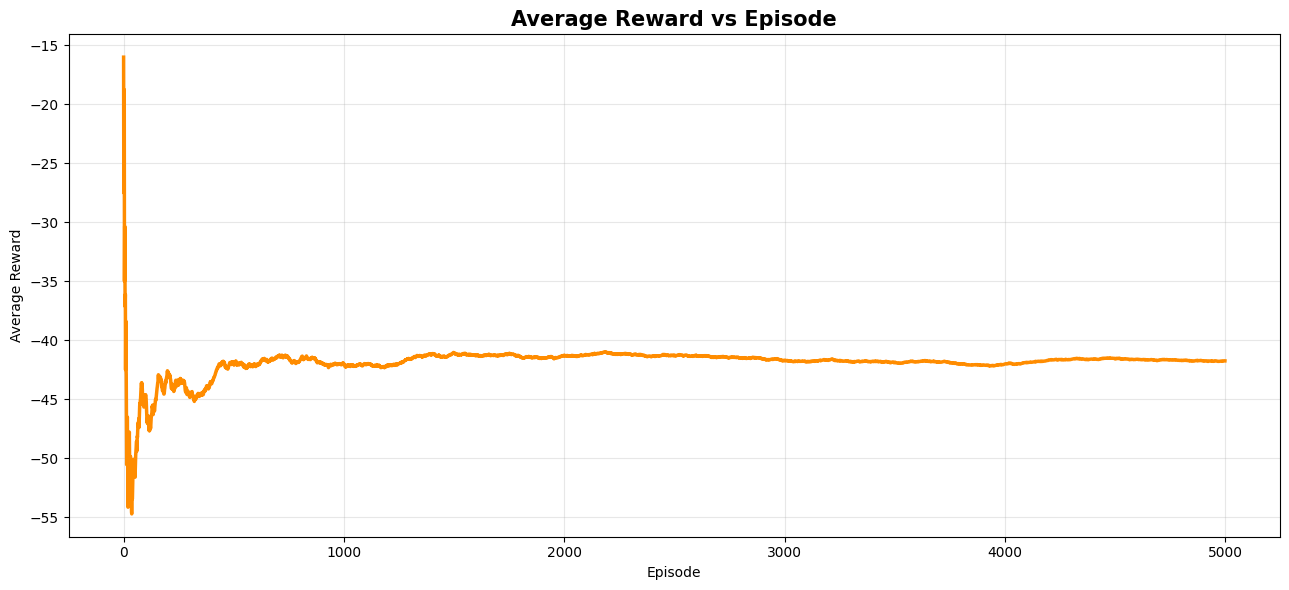

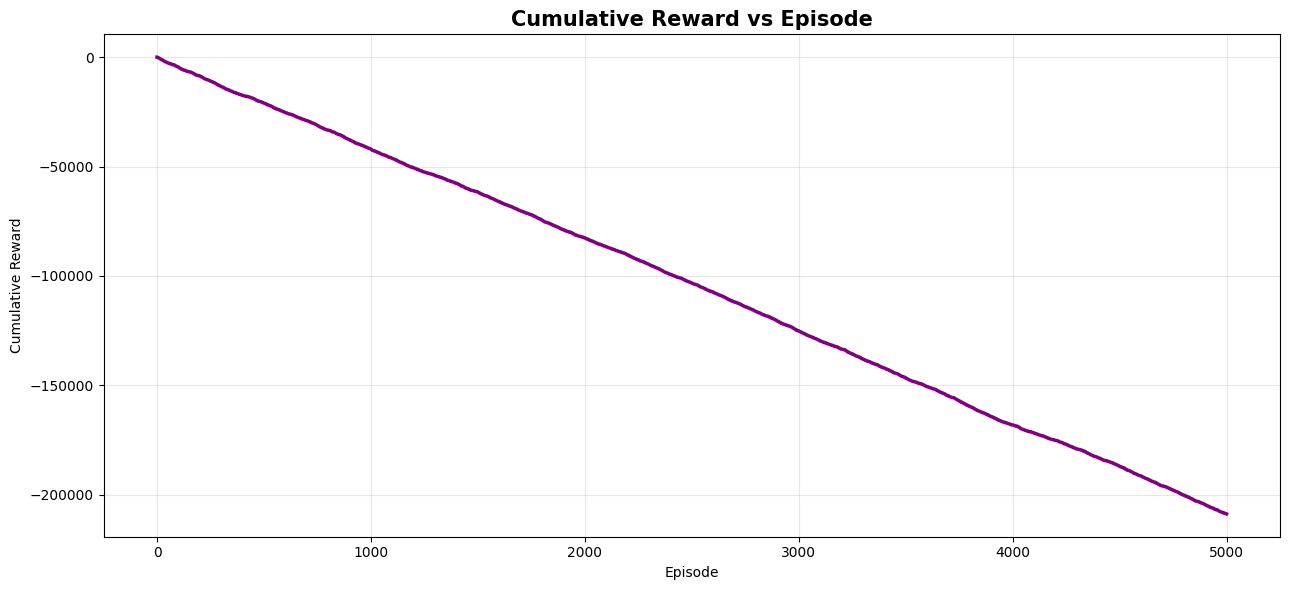

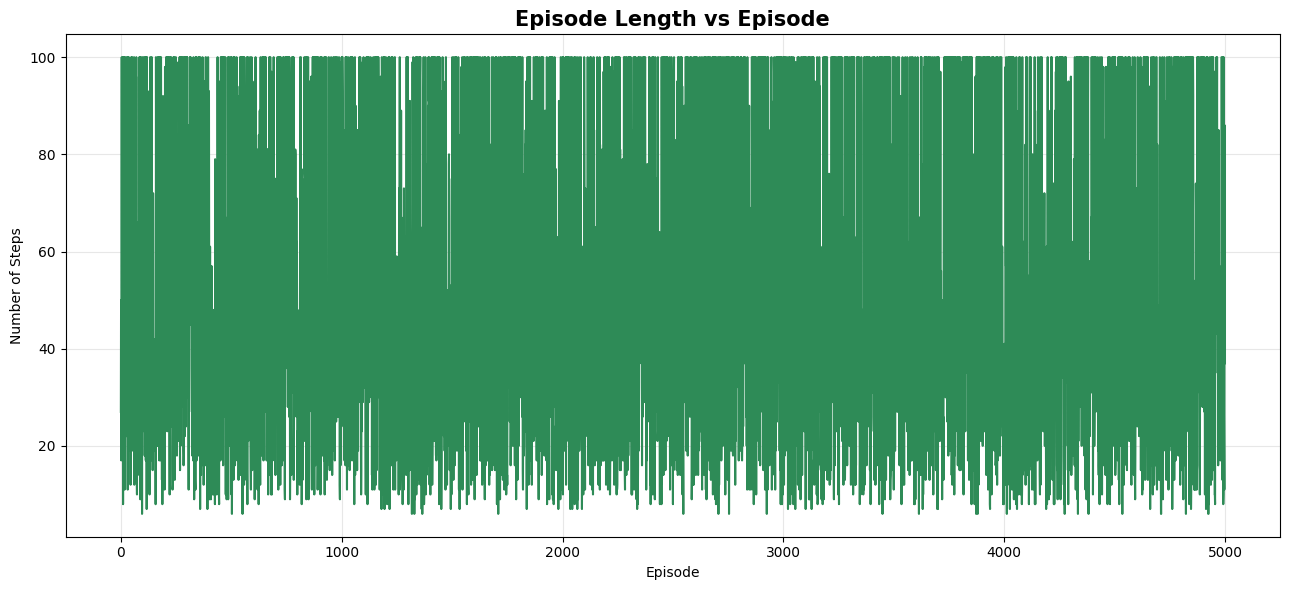

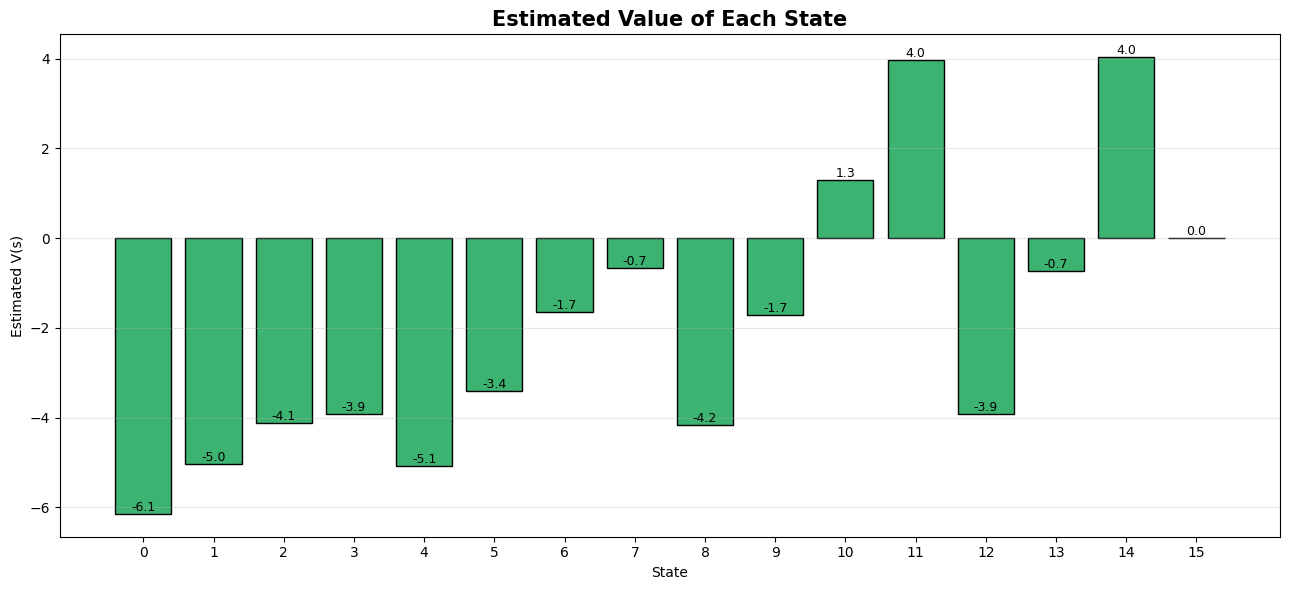

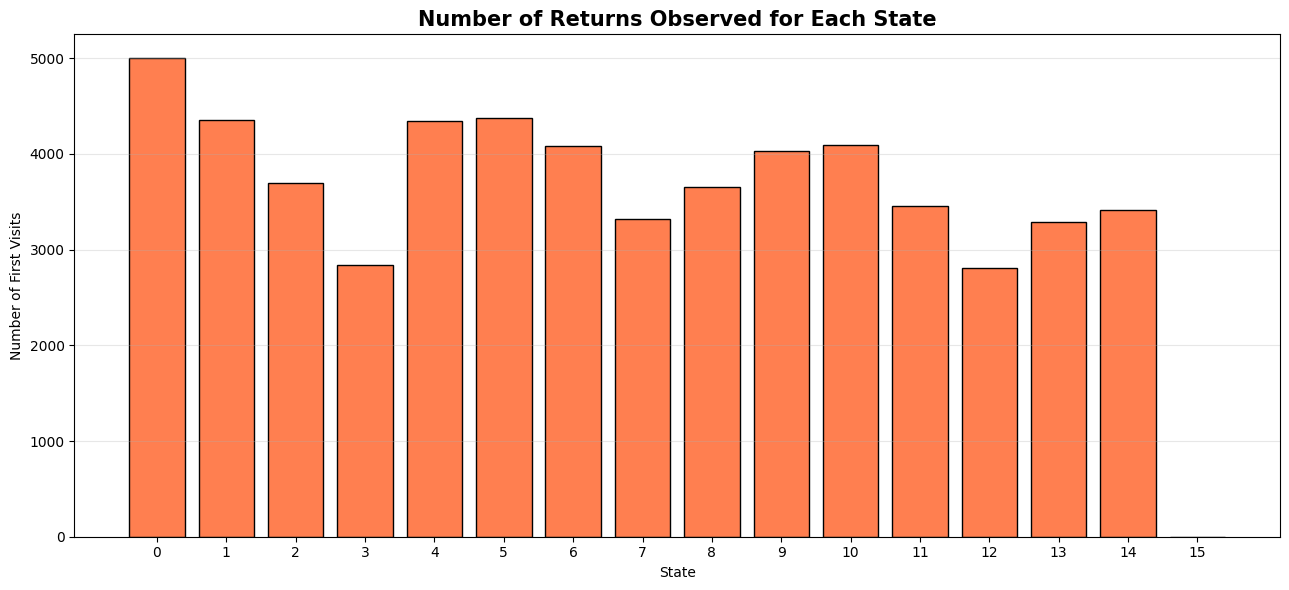


FINAL RESULT

Episodes Used                 : 5000
Number of States              : 16
Number of Actions             : 4
Discount Factor (Gamma)        : 0.9
Start State                    : 0
Goal State                     : 15

Estimated Value of Start State: -6.1430
Goal State Value               : 0.0000

Average Episode Reward         : -41.7404
Maximum Episode Reward         : 5.0000
Minimum Episode Reward         : -100.0000

Average Episode Length         : 50.93

CSV FILES GENERATED

1. monte_carlo_state_summary.csv
2. monte_carlo_performance_metrics.csv
3. monte_carlo_episode_summary.csv


MONTE CARLO PREDICTION EXPERIMENT COMPLETED SUCCESSFULLY

MONTE CARLO PREDICTION - SUMMARY TABLE
                  Parameter                             Result
                  Algorithm First-Visit Monte Carlo Prediction
                Environment                    4 x 4 Gridworld
           Number of States                                 16
          Number of Actions                 

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ======================================================================
# 4. ENVIRONMENT PARAMETERS
# ======================================================================

ROWS = 4
COLS = 4
NUM_STATES = ROWS * COLS

NUM_ACTIONS = 4

# Actions
# 0 = UP
# 1 = DOWN
# 2 = LEFT
# 3 = RIGHT

ACTIONS = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT"
}

# Start and terminal states
START_STATE = 0
GOAL_STATE = 15

# Reward structure
STEP_REWARD = -1
GOAL_REWARD = 10

# Discount factor
GAMMA = 0.9

# Number of episodes
EPISODES = 5000

# Maximum steps in one episode
MAX_STEPS = 100

# Reproducibility
np.random.seed(42)

# ======================================================================
# 5. GRIDWORLD FUNCTIONS
# ======================================================================

def state_to_position(state):
    """
    Convert state number into row and column.
    """
    return divmod(state, COLS)


def position_to_state(row, col):
    """
    Convert row and column into state number.
    """
    return row * COLS + col


def next_state(state, action):
    """
    Return the next state after performing an action.

    If the agent tries to move outside the grid,
    it remains in the same state.
    """

    # Terminal state remains terminal
    if state == GOAL_STATE:
        return state

    row, col = state_to_position(state)

    if action == 0:       # UP
        row = max(0, row - 1)

    elif action == 1:     # DOWN
        row = min(ROWS - 1, row + 1)

    elif action == 2:     # LEFT
        col = max(0, col - 1)

    elif action == 3:     # RIGHT
        col = min(COLS - 1, col + 1)

    return position_to_state(row, col)


def get_reward(next_s):
    """
    Reward function.

    Reaching goal -> +10
    Normal movement -> -1
    """

    if next_s == GOAL_STATE:
        return GOAL_REWARD

    return STEP_REWARD


# ======================================================================
# 6. GRIDWORLD DISPLAY
# ======================================================================

print("\n" + "=" * 90)
print("GRIDWORLD ENVIRONMENT")
print("=" * 90)

for row in range(ROWS):

    row_display = []

    for col in range(COLS):

        state = position_to_state(
            row,
            col
        )

        if state == START_STATE:
            label = "S"

        elif state == GOAL_STATE:
            label = "G"

        else:
            label = str(state)

        row_display.append(
            f"{label:^6}"
        )

    print("|".join(row_display))

print("\nS = Start State")
print("G = Terminal Goal State")

# ======================================================================
# 7. RANDOM POLICY
# ======================================================================

def random_policy(state):
    """
    Random policy.

    Each action has equal probability.
    """

    return np.random.randint(
        NUM_ACTIONS
    )


# ======================================================================
# 8. GENERATE ONE COMPLETE EPISODE
# ======================================================================

def generate_episode():

    states = []
    rewards = []

    state = START_STATE

    for step in range(MAX_STEPS):

        # Select an action according to random policy
        action = random_policy(state)

        # Move to next state
        next_s = next_state(
            state,
            action
        )

        # Get reward
        reward = get_reward(
            next_s
        )

        # Store current state and reward
        states.append(state)
        rewards.append(reward)

        # Move to next state
        state = next_s

        # Stop when goal is reached
        if state == GOAL_STATE:
            break

    return states, rewards


# ======================================================================
# 9. MONTE CARLO PREDICTION
# ======================================================================

def monte_carlo_prediction():

    # --------------------------------------------------------------
    # Value function initialized to zero
    # --------------------------------------------------------------

    values = np.zeros(
        NUM_STATES
    )

    # Store returns observed for every state
    returns = [
        []
        for _ in range(NUM_STATES)
    ]

    # Track learning performance
    episode_rewards = np.zeros(
        EPISODES
    )

    episode_lengths = np.zeros(
        EPISODES
    )

    value_history = []

    # --------------------------------------------------------------
    # Generate episodes
    # --------------------------------------------------------------

    for episode in range(EPISODES):

        states, rewards = generate_episode()

        # Total reward of episode
        episode_rewards[episode] = np.sum(
            rewards
        )

        # Episode length
        episode_lengths[episode] = len(
            states
        )

        # ----------------------------------------------------------
        # Calculate Returns
        # ----------------------------------------------------------

        G = 0

        visited_states = set()

        # Process episode backwards
        for t in reversed(
            range(len(states))
        ):

            state = states[t]

            reward = rewards[t]

            # Calculate discounted return
            G = (
                GAMMA * G +
                reward
            )

            # First-Visit Monte Carlo
            if state not in visited_states:

                visited_states.add(
                    state
                )

                # Store return
                returns[state].append(
                    G
                )

                # Update value estimate
                values[state] = np.mean(
                    returns[state]
                )

        # Store value function periodically
        if (
            episode < 100 or
            (episode + 1) % 100 == 0
        ):

            value_history.append(
                values.copy()
            )

    return (
        values,
        returns,
        episode_rewards,
        episode_lengths,
        value_history
    )


# ======================================================================
# 10. RUN MONTE CARLO PREDICTION
# ======================================================================

print("\n" + "=" * 90)
print("RUNNING MONTE CARLO PREDICTION")
print("=" * 90)

(
    learned_values,
    state_returns,
    episode_rewards,
    episode_lengths,
    value_history
) = monte_carlo_prediction()

print(
    f"\nMonte Carlo Prediction completed for "
    f"{EPISODES} episodes."
)

# ======================================================================
# 11. VALUE FUNCTION DISPLAY
# ======================================================================

print("\n" + "=" * 90)
print("LEARNED STATE-VALUE FUNCTION")
print("=" * 90)

value_grid = learned_values.reshape(
    ROWS,
    COLS
)

print(
    np.round(
        value_grid,
        3
    )
)

# ======================================================================
# 12. STATE-WISE SUMMARY TABLE
# ======================================================================

state_summary = []

for state in range(NUM_STATES):

    row, col = state_to_position(
        state
    )

    if state == GOAL_STATE:
        state_type = "Terminal"

    elif state == START_STATE:
        state_type = "Start"

    else:
        state_type = "Normal"

    state_summary.append({
        "State": state,
        "Row": row,
        "Column": col,
        "State Type": state_type,
        "Estimated Value": round(
            learned_values[state],
            4
        ),
        "Number of Returns": len(
            state_returns[state]
        )
    })

state_summary_df = pd.DataFrame(
    state_summary
)

# ======================================================================
# 13. PERFORMANCE METRICS
# ======================================================================

average_episode_reward = np.mean(
    episode_rewards
)

maximum_episode_reward = np.max(
    episode_rewards
)

minimum_episode_reward = np.min(
    episode_rewards
)

average_episode_length = np.mean(
    episode_lengths
)

maximum_episode_length = np.max(
    episode_lengths
)

minimum_episode_length = np.min(
    episode_lengths
)

start_state_value = learned_values[
    START_STATE
]

goal_state_value = learned_values[
    GOAL_STATE
]

number_of_states_visited = sum(
    len(returns) > 0
    for returns in state_returns
)

performance_df = pd.DataFrame({
    "Metric": [
        "Number of States",
        "Number of Actions",
        "Episodes",
        "Discount Factor",
        "Start State",
        "Goal State",
        "Start State Estimated Value",
        "Goal State Value",
        "Average Episode Reward",
        "Maximum Episode Reward",
        "Minimum Episode Reward",
        "Average Episode Length",
        "Maximum Episode Length",
        "Minimum Episode Length",
        "States with Observed Returns"
    ],

    "Value": [
        NUM_STATES,
        NUM_ACTIONS,
        EPISODES,
        GAMMA,
        START_STATE,
        GOAL_STATE,
        round(
            start_state_value,
            4
        ),
        round(
            goal_state_value,
            4
        ),
        round(
            average_episode_reward,
            4
        ),
        round(
            maximum_episode_reward,
            4
        ),
        round(
            minimum_episode_reward,
            4
        ),
        round(
            average_episode_length,
            4
        ),
        int(
            maximum_episode_length
        ),
        int(
            minimum_episode_length
        ),
        number_of_states_visited
    ]
})

# ======================================================================
# 14. EPISODE SUMMARY TABLE
# ======================================================================

episode_summary_df = pd.DataFrame({
    "Episode": np.arange(
        1,
        EPISODES + 1
    ),

    "Episode Reward": np.round(
        episode_rewards,
        4
    ),

    "Episode Length": episode_lengths.astype(
        int
    )
})

episode_summary_df["Cumulative Reward"] = np.cumsum(
    episode_rewards
)

episode_summary_df["Average Reward"] = (
    np.cumsum(
        episode_rewards
    ) /
    np.arange(
        1,
        EPISODES + 1
    )
)

# ======================================================================
# 15. EXPORT CSV FILES
# ======================================================================

state_summary_df.to_csv(
    "monte_carlo_state_summary.csv",
    index=False
)

performance_df.to_csv(
    "monte_carlo_performance_metrics.csv",
    index=False
)

episode_summary_df.to_csv(
    "monte_carlo_episode_summary.csv",
    index=False
)

# ======================================================================
# 16. DISPLAY STATE SUMMARY
# ======================================================================

print("\n" + "=" * 90)
print("STATE-VALUE SUMMARY TABLE")
print("=" * 90)

print(
    state_summary_df.to_string(
        index=False
    )
)

# ======================================================================
# 17. DISPLAY PERFORMANCE METRICS
# ======================================================================

print("\n" + "=" * 90)
print("PERFORMANCE METRICS")
print("=" * 90)

print(
    performance_df.to_string(
        index=False
    )
)

# ======================================================================
# 18. VISUALIZATION 1
# STATE VALUE FUNCTION
# ======================================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    value_grid,
    cmap="viridis"
)

plt.colorbar(
    label="Estimated State Value"
)

plt.title(
    "Monte Carlo Prediction - State Value Function",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Column"
)

plt.ylabel(
    "Row"
)

for row in range(ROWS):

    for col in range(COLS):

        state = position_to_state(
            row,
            col
        )

        value = learned_values[
            state
        ]

        if state == GOAL_STATE:

            text = "G"

        elif state == START_STATE:

            text = f"S\n{value:.2f}"

        else:

            text = f"{value:.2f}"

        plt.text(
            col,
            row,
            text,
            ha="center",
            va="center",
            color="white",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

# ======================================================================
# 19. VISUALIZATION 2
# EPISODE REWARD
# ======================================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    episode_rewards,
    color="royalblue",
    alpha=0.6,
    linewidth=1,
    label="Episode Reward"
)

# Running average
running_average = (
    np.cumsum(
        episode_rewards
    ) /
    np.arange(
        1,
        EPISODES + 1
    )
)

plt.plot(
    running_average,
    color="red",
    linewidth=2.5,
    label="Running Average Reward"
)

plt.title(
    "Monte Carlo Episode Reward",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Reward"
)

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ======================================================================
# 20. VISUALIZATION 3
# AVERAGE REWARD
# ======================================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    episode_summary_df["Average Reward"],
    color="darkorange",
    linewidth=2.5
)

plt.title(
    "Average Reward vs Episode",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Average Reward"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ======================================================================
# 21. VISUALIZATION 4
# CUMULATIVE REWARD
# ======================================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    episode_summary_df["Cumulative Reward"],
    color="purple",
    linewidth=2.5
)

plt.title(
    "Cumulative Reward vs Episode",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Cumulative Reward"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ======================================================================
# 22. VISUALIZATION 5
# EPISODE LENGTH
# ======================================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    episode_lengths,
    color="seagreen",
    linewidth=1.5
)

plt.title(
    "Episode Length vs Episode",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Number of Steps"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ======================================================================
# 23. VISUALIZATION 6
# STATE VALUE BAR CHART
# ======================================================================

plt.figure(
    figsize=(13, 6)
)

bars = plt.bar(
    np.arange(NUM_STATES),
    learned_values,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title(
    "Estimated Value of Each State",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "State"
)

plt.ylabel(
    "Estimated V(s)"
)

plt.xticks(
    np.arange(NUM_STATES)
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    learned_values
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ======================================================================
# 24. VISUALIZATION 7
# NUMBER OF RETURNS PER STATE
# ======================================================================

return_counts = [
    len(state_returns[state])
    for state in range(NUM_STATES)
]

plt.figure(
    figsize=(13, 6)
)

plt.bar(
    np.arange(NUM_STATES),
    return_counts,
    color="coral",
    edgecolor="black"
)

plt.title(
    "Number of Returns Observed for Each State",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "State"
)

plt.ylabel(
    "Number of First Visits"
)

plt.xticks(
    np.arange(NUM_STATES)
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ======================================================================
# 25. FINAL RESULT
# ======================================================================

print("\n" + "=" * 90)
print("FINAL RESULT")
print("=" * 90)

print(
    f"\nEpisodes Used                 : {EPISODES}"
)

print(
    f"Number of States              : {NUM_STATES}"
)

print(
    f"Number of Actions             : {NUM_ACTIONS}"
)

print(
    f"Discount Factor (Gamma)        : {GAMMA}"
)

print(
    f"Start State                    : {START_STATE}"
)

print(
    f"Goal State                     : {GOAL_STATE}"
)

print(
    f"\nEstimated Value of Start State: "
    f"{start_state_value:.4f}"
)

print(
    f"Goal State Value               : "
    f"{goal_state_value:.4f}"
)

print(
    f"\nAverage Episode Reward         : "
    f"{average_episode_reward:.4f}"
)

print(
    f"Maximum Episode Reward         : "
    f"{maximum_episode_reward:.4f}"
)

print(
    f"Minimum Episode Reward         : "
    f"{minimum_episode_reward:.4f}"
)

print(
    f"\nAverage Episode Length         : "
    f"{average_episode_length:.2f}"
)

# ======================================================================
# 27. CSV FILES
# ======================================================================

print("\n" + "=" * 90)
print("CSV FILES GENERATED")
print("=" * 90)

print(
"""
1. monte_carlo_state_summary.csv
2. monte_carlo_performance_metrics.csv
3. monte_carlo_episode_summary.csv
"""
)

print("\n" + "=" * 90)
print("MONTE CARLO PREDICTION EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 90)
# =====================================================================
# SUMMARY TABLE - MONTE CARLO PREDICTION
# =====================================================================

summary_table = pd.DataFrame({
    "Parameter": [
        "Algorithm",
        "Environment",
        "Number of States",
        "Number of Actions",
        "Number of Episodes",
        "Discount Factor (Gamma)",
        "Start State",
        "Goal State",
        "Estimated Start State Value",
        "Average Episode Reward",
        "Maximum Episode Reward",
        "Minimum Episode Reward",
        "Average Episode Length",
        "States Visited",
        "Prediction Method"
    ],

    "Result": [
        "First-Visit Monte Carlo Prediction",
        "4 x 4 Gridworld",
        NUM_STATES,
        NUM_ACTIONS,
        EPISODES,
        GAMMA,
        START_STATE,
        GOAL_STATE,
        round(start_state_value, 4),
        round(average_episode_reward, 4),
        round(maximum_episode_reward, 4),
        round(minimum_episode_reward, 4),
        round(average_episode_length, 2),
        number_of_states_visited,
        "Average of First-Visit Returns"
    ]
})

# Display Summary Table
print("\n" + "=" * 90)
print("MONTE CARLO PREDICTION - SUMMARY TABLE")
print("=" * 90)

print(
    summary_table.to_string(index=False)
)

# =====================================================================
# EXPORT SUMMARY TABLE
# =====================================================================

summary_table.to_csv(
    "monte_carlo_summary_table.csv",
    index=False
)

print("\nSummary table exported successfully as:")
print("monte_carlo_summary_table.csv")